   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.4 MB/s eta 0:00:00
first 5 rows :    Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv

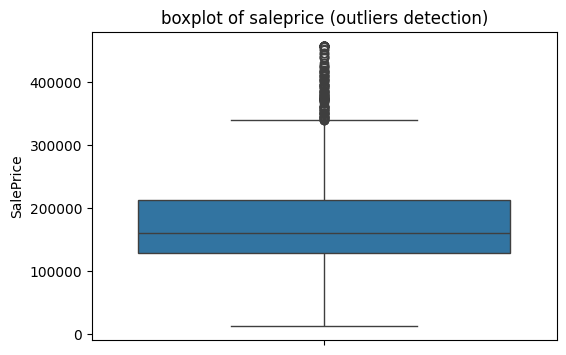

In [1]:
! pip install import-ipynb
import import_ipynb
import Phase_1_ipynb
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
path= "/content/AmesHousing.csv"
df = pd.read_csv(path)
from Phase_1_ipynb import clean_data
df= clean_data(df)
df.columns

missing in saleprice: 0
Duplicates: 0
min saleprice: 12789.0


Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [3]:
# price per square foot (add +1) to avoid division by zero
df["price_per_sqft"] = df["SalePrice"] / (df["Gr Liv Area"] + 1)
#total bathrooms(half bath counts as 0.5)
df["total_bathrooms"] = df["Full Bath"] + 0.5 * df ["Half Bath"]

Text(0.5, 1.0, 'SalePrice Distribution Before Log')

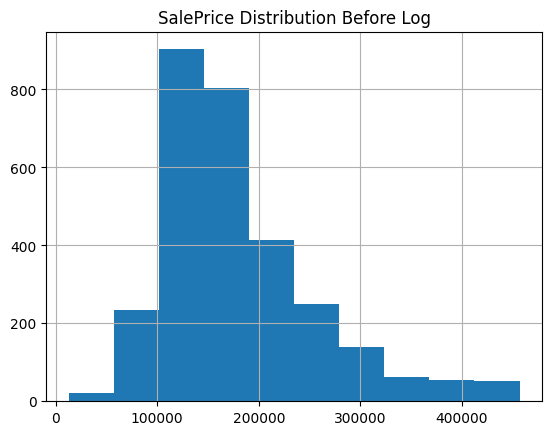

In [4]:
# feature interaction between living area and lot size
df["area_x_lot"] = df["Gr Liv Area"] * df["Lot Area"]
df["SalePrice"].hist()
plt.title("SalePrice Distribution Before Log")

Text(0.5, 1.0, 'SalePrice Distribution After Log')

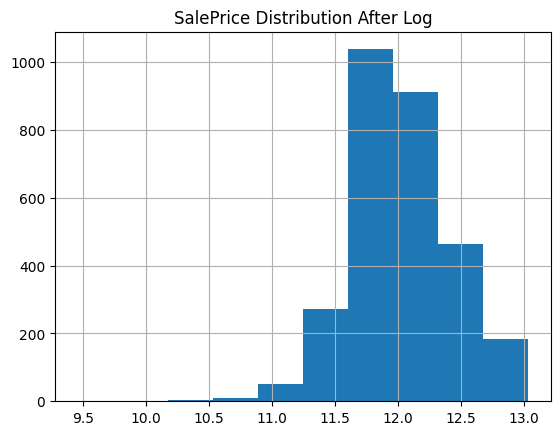

In [5]:
#log transform to reduce skewness
df["SalePrice_log"] = np.log1p(df["SalePrice"])
df["SalePrice_log"].hist()
plt.title("SalePrice Distribution After Log")


In [6]:
#house age calculation
df["house_age"] = df["Yr Sold"] - df["Year Built"]
#categorize house age into groups
df["age_group"] = pd.cut(df["house_age"],
                         bins= [0,10,30,100],
                         labels = ["New", "Recent", "Old"])

In [7]:
scaler = StandardScaler()
cols_to_scale = ["Gr Liv Area", "SalePrice"]
#standardization ( mean= 0 , std= 1)
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [8]:
# correlation matrix ( absolute valuse)
corr_matrix = df.corr(numeric_only= True).abs()
#keep only upper triange to avoid duplicate pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
# find highly correlated features (>0.95)
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
# drop redundant
df.drop(columns=to_drop, inplace=True)